In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../src")
import dlc_processing as dlc
import pingouin as pg
from dlc_processing import kinematicsAnalysis
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
loc1 = r'G:\Shared drives\Turi_lab\Data\PTSD_project\DLC_and_Moseq\body_length.csv'
loc2 = r'G:\Shared drives\Turi_lab\Data\PTSD_project\DLC_and_Moseq\curvature.csv'
loc3 = r'G:\Shared drives\Turi_lab\Data\PTSD_project\metadata.csv'

bl_df = pd.read_csv(loc1)
curv_df = pd.read_csv(loc2)
metadata = pd.read_csv(loc3)

working_group = ['ptsd2', 'ptsd3', 'ptsd4', 'ptsd5', 'ptsd6', 'ptsd9']
metadata['cohort'] = metadata['cohort_id'].str.split('_').str[0]
metadata = metadata[metadata['cohort'].isin(working_group)]
metadata['cohort_id'] = metadata['cohort_id'].str.replace('-', '_', regex=False)
metadata['young'] = metadata['young'].map({True: 'Young Adult', False: 'Adult'})


In [3]:
curv_df = curv_df.merge(metadata[['cohort_id', 'condition', 'sex', 'young']], on='cohort_id', how='left')
bl_df = bl_df.merge(metadata[['cohort_id', 'condition', 'sex', 'young']], on='cohort_id', how='left')

In [4]:
curv_summary = curv_df.groupby(['cohort_id', 'day']).agg({
    'spine_curvature': 'mean',  
    'condition': 'first', 
    'sex': 'first',   
    'young': 'first' 
}).reset_index()

curv_summary.head()

,cohort_id,day,spine_curvature,condition,sex,young
0,ptsd2_81,recall1,6.826736,control,male,Young Adult
1,ptsd2_81,recall4,6.940273,control,male,Young Adult
2,ptsd2_82,recall1,6.772380,control,male,Young Adult
3,ptsd2_82,recall4,6.767650,control,male,Young Adult
4,ptsd2_83,recall1,6.966562,sefl,male,Young Adult


In [5]:
bl_summary = bl_df.groupby(['cohort_id', 'day']).agg({
    'body_length': 'mean',  
    'condition': 'first', 
    'sex': 'first',   
    'young': 'first' 
}).reset_index()

bl_summary.head()

,cohort_id,day,body_length,condition,sex,young
0,ptsd2_81,recall1,88.730625,control,male,Young Adult
1,ptsd2_81,recall4,92.355822,control,male,Young Adult
2,ptsd2_82,recall1,97.404667,control,male,Young Adult
3,ptsd2_82,recall4,145.167092,control,male,Young Adult
4,ptsd2_83,recall1,90.627523,sefl,male,Young Adult


Text(0.5, 0, 'Day')

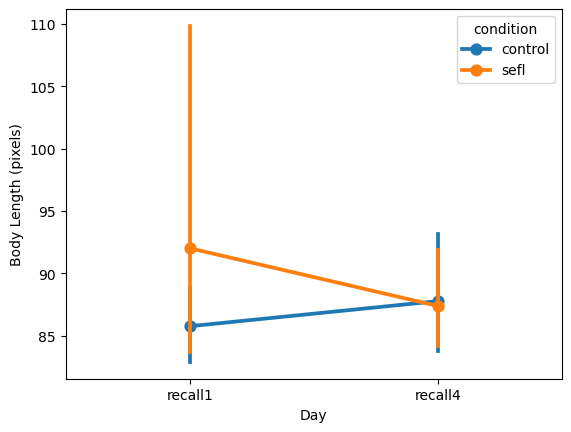

In [6]:
ax = sns.pointplot(data=bl_summary,
              x='day',
              y='body_length',
              hue='condition')

# ax.set_title('Body Length Comparison')
ax.set_ylabel('Body Length (pixels)')
ax.set_xlabel('Day')


In [7]:
tools = kinematicsAnalysis(bl_summary)
result = tools.repeated_measures_anova(
    dv='body_length',
    within='day',
    between='condition',
    subject='cohort_id'
)
print("Repeated ANOVA Result for conditional comparison:")
print(result['anova_result'])
print(f"Required Sample Size per Group: {result['required_sample_size']:.4f}")

post_hoc_result = tools.post_hoc_analysis_significant(
    dv='body_length',
    within='day',
    between='condition',
    subject='cohort_id'
)

print("Repeated ANOVA Post-hoc analysis pairwise t-test result for conditional comparison:")
print(post_hoc_result)


Repeated ANOVA Result for conditional comparison:
        Source          SS  DF1  DF2          MS         F     p-unc  \
0    condition  312.409700    1   63  312.409700  0.480956  0.490538   
1          day  186.328640    1   63  186.328640  0.297187  0.587576   
2  Interaction  394.858057    1   63  394.858057  0.629784  0.430413   

        np2  eps  
0  0.007576  NaN  
1  0.004695  1.0  
2  0.009898  NaN  
Required Sample Size per Group: 515.0193
Repeated ANOVA Post-hoc analysis pairwise t-test result for conditional comparison:
Empty DataFrame
Columns: [Contrast, day, A, B, p-corr, Cohen'd]
Index: []


Text(58.097222222222214, 0.5, 'Body Length (pixels)')

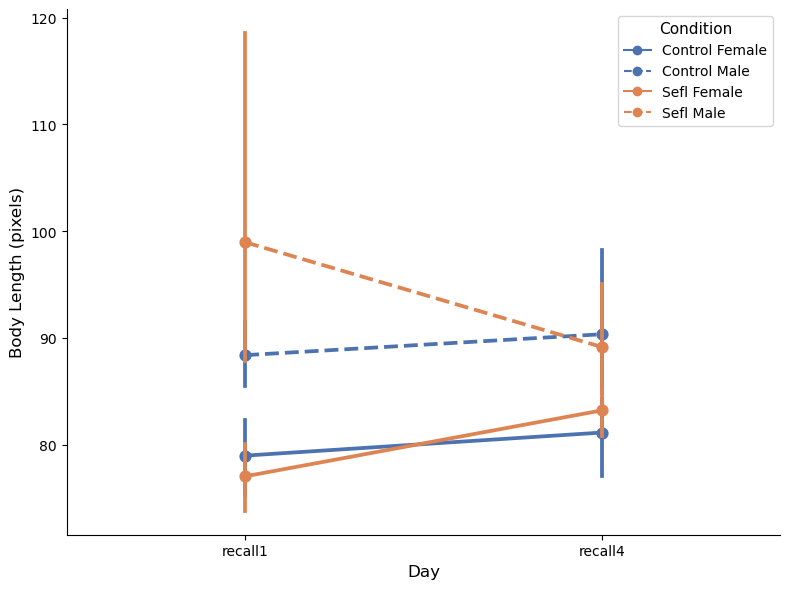

In [8]:
dlc.plot_kinematics_pointplot(bl_summary, ['condition', 'sex'])
plt.ylabel('Body Length (pixels)')

In [13]:
bl_male = bl_summary[bl_summary["sex"] == "male"]

tools_male = kinematicsAnalysis(bl_male)

result_male = tools_male.repeated_measures_anova(
    dv="body_length",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Male-Only ANOVA Result:")
print(result_male["anova_result"])


Male-Only ANOVA Result:
        Source          SS  DF1  DF2          MS         F     p-unc  \
0    condition  482.006901    1   44  482.006901  0.585739  0.448158   
1          day  622.326779    1   44  622.326779  0.716274  0.401948   
2  Interaction  758.101317    1   44  758.101317  0.872545  0.355350   

        np2  eps  
0  0.013137  NaN  
1  0.016018  1.0  
2  0.019445  NaN  


In [14]:
bl_female = bl_summary[bl_summary["sex"] == "female"]

tools_female = kinematicsAnalysis(bl_female)

result_female = tools_female.repeated_measures_anova(
    dv="body_length",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Female-Only ANOVA Result:")
print(result_female["anova_result"])


Female-Only ANOVA Result:
        Source          SS  DF1  DF2          MS          F     p-unc  \
0    condition    0.786911    1   17    0.786911   0.019376  0.890929   
1          day  184.103544    1   17  184.103544  12.075888  0.002897   
2  Interaction   27.908889    1   17   27.908889   1.830625  0.193775   

        np2  eps  
0  0.001138  NaN  
1  0.415323  1.0  
2  0.097215  NaN  


In [24]:
bl_recall1 = bl_summary[bl_summary["day"] == "recall1"]

# Fit the ANOVA model
model1 = ols("body_length ~ C(condition) * C(sex)", data=bl_recall1).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Sex at Recall1:")
print(anova_table1)


bl_recall4 = bl_summary[bl_summary["day"] == "recall4"]

# Fit the ANOVA model
model2 = ols("body_length ~ C(condition) * C(sex)", data=bl_recall4).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Sex at Recall4:")
print(anova_table2)




Two-Way ANOVA for Condition × Sex at Recall1:
                           sum_sq    df         F    PR(>F)
C(condition)           738.452602   1.0  0.696499  0.407167
C(sex)                4206.291801   1.0  3.967323  0.050801
C(condition):C(sex)    503.198797   1.0  0.474611  0.493444
Residual             65734.529487  62.0       NaN       NaN
Two-Way ANOVA for Condition × Sex at Recall4:
                          sum_sq    df         F    PR(>F)
C(condition)            0.981301   1.0  0.006181  0.937594
C(sex)                689.600129   1.0  4.343450  0.041347
C(condition):C(sex)    33.615474   1.0  0.211727  0.647053
Residual             9684.838514  61.0       NaN       NaN


Text(58.097222222222214, 0.5, 'Body Length (pixels)')

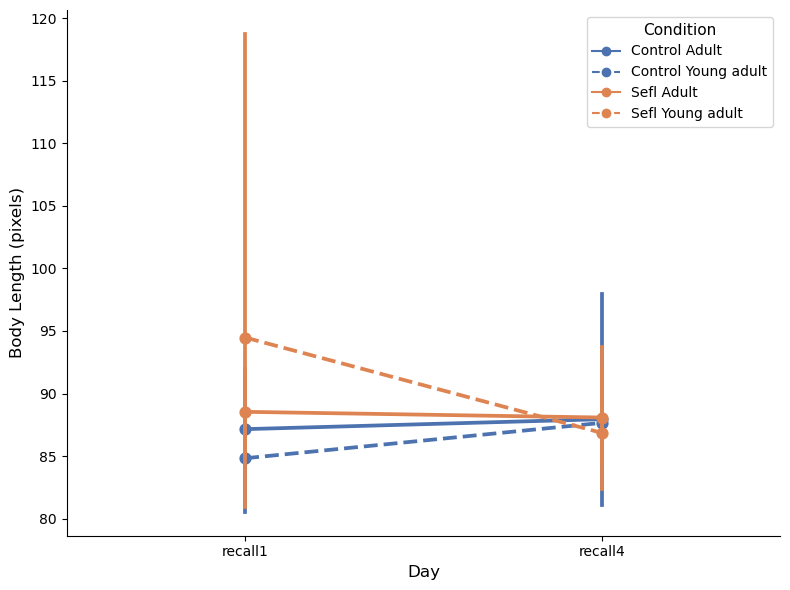

In [9]:
dlc.plot_kinematics_pointplot(bl_summary, ['condition', 'young'])
plt.ylabel('Body Length (pixels)')

In [27]:
bl_ya = bl_summary[bl_summary["young"] == "Young Adult"]

tools_ya = kinematicsAnalysis(bl_ya)

result_ya = tools_ya.repeated_measures_anova(
    dv="body_length",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Young Adult-Only ANOVA Result:")
print(result_ya["anova_result"])


Young Adult-Only ANOVA Result:
        Source          SS  DF1  DF2          MS         F     p-unc  \
0    condition  440.094229    1   36  440.094229  0.408565  0.526745   
1          day  319.595260    1   36  319.595260  0.297300  0.588943   
2  Interaction  594.973693    1   36  594.973693  0.553467  0.461733   

        np2  eps  
0  0.011222  NaN  
1  0.008191  1.0  
2  0.015141  NaN  


In [28]:
bl_ad = bl_summary[bl_summary["young"] == "Adult"]

tools_ad = kinematicsAnalysis(bl_ad)

result_ad = tools_ad.repeated_measures_anova(
    dv="body_length",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Adult-Only ANOVA Result:")
print(result_ad["anova_result"])


Adult-Only ANOVA Result:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  7.269818    1   25  7.269818  0.092529  0.763503  0.003688   
1          day  0.000844    1   25  0.000844  0.000046  0.994656  0.000002   
2  Interaction  4.912776    1   25  4.912776  0.266261  0.610385  0.010538   

   eps  
0  NaN  
1  1.0  
2  NaN  


In [25]:
bl_recall1 = bl_summary[bl_summary["day"] == "recall1"]

# Fit the ANOVA model
model3 = ols("body_length ~ C(condition) * C(young)", data=bl_recall1).fit()
anova_table3 = sm.stats.anova_lm(model3, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Age at Recall1:")
print(anova_table3)


bl_recall4 = bl_summary[bl_summary["day"] == "recall4"]

# Fit the ANOVA model
model4 = ols("body_length ~ C(condition) * C(young)", data=bl_recall4).fit()
anova_table4 = sm.stats.anova_lm(model4, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Age at Recall4:")
print(anova_table4)




Two-Way ANOVA for Condition × Age at Recall1:
                             sum_sq    df         F    PR(>F)
C(condition)             615.839222   1.0  0.544986  0.463159
C(young)                 127.805903   1.0  0.113102  0.737776
C(condition):C(young)    255.681124   1.0  0.226265  0.635979
Residual               70060.533059  62.0       NaN       NaN
Two-Way ANOVA for Condition × Age at Recall4:
                             sum_sq    df         F    PR(>F)
C(condition)               2.682269   1.0  0.015743  0.900562
C(young)                  11.996619   1.0  0.070414  0.791630
C(condition):C(young)      3.259363   1.0  0.019131  0.890448
Residual               10392.798135  61.0       NaN       NaN


Text(0.5, 0, 'Day')

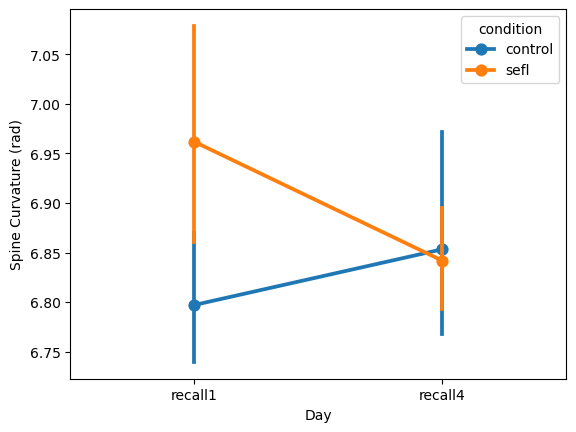

In [10]:
ax = sns.pointplot(data=curv_summary,
              x='day',
              y='spine_curvature',
              hue='condition')

# ax.set_title('Body Length Comparison')
ax.set_ylabel('Spine Curvature (rad)')
ax.set_xlabel('Day')


In [29]:
curv_summary

,cohort_id,day,spine_curvature,condition,sex,young
0,ptsd2_81,recall1,6.826736,control,male,Young Adult
1,ptsd2_81,recall4,6.940273,control,male,Young Adult
2,ptsd2_82,recall1,6.772380,control,male,Young Adult
3,ptsd2_82,recall4,6.767650,control,male,Young Adult
4,ptsd2_83,recall1,6.966562,sefl,male,Young Adult
...,...,...,...,...,...,...
135,ptsd9_31_1,recall4,6.760502,sefl,male,Adult
136,ptsd9_31_2,recall1,7.598458,sefl,male,Adult
137,ptsd9_31_2,recall4,6.624942,sefl,male,Adult
138,ptsd9_31_5,recall1,6.622174,control,male,Adult


In [30]:
tools = kinematicsAnalysis(curv_summary)
result = tools.repeated_measures_anova(
    dv='spine_curvature',
    within='day',
    between='condition',
    subject='cohort_id'
)
print("Repeated ANOVA Result for conditional comparison:")
print(result['anova_result'])
print(f"Required Sample Size per Group: {result['required_sample_size']:.4f}")

post_hoc_result = tools.post_hoc_analysis_significant(
    dv='spine_curvature',
    within='day',
    between='condition',
    subject='cohort_id'
)

print("Repeated ANOVA Post-hoc analysis pairwise t-test result for conditional comparison:")
print(post_hoc_result)


Repeated ANOVA Result for conditional comparison:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.138429    1   63  0.138429  2.083601  0.153843  0.032014   
1          day  0.053129    1   63  0.053129  0.793860  0.376326  0.012444   
2  Interaction  0.189830    1   63  0.189830  2.836464  0.097096  0.043083   

   eps  
0  NaN  
1  1.0  
2  NaN  
Required Sample Size per Group: 119.6275
Repeated ANOVA Post-hoc analysis pairwise t-test result for conditional comparison:
Empty DataFrame
Columns: [Contrast, day, A, B, p-corr, Cohen'd]
Index: []


Text(62.597222222222214, 0.5, 'Spine Curvature (rad)')

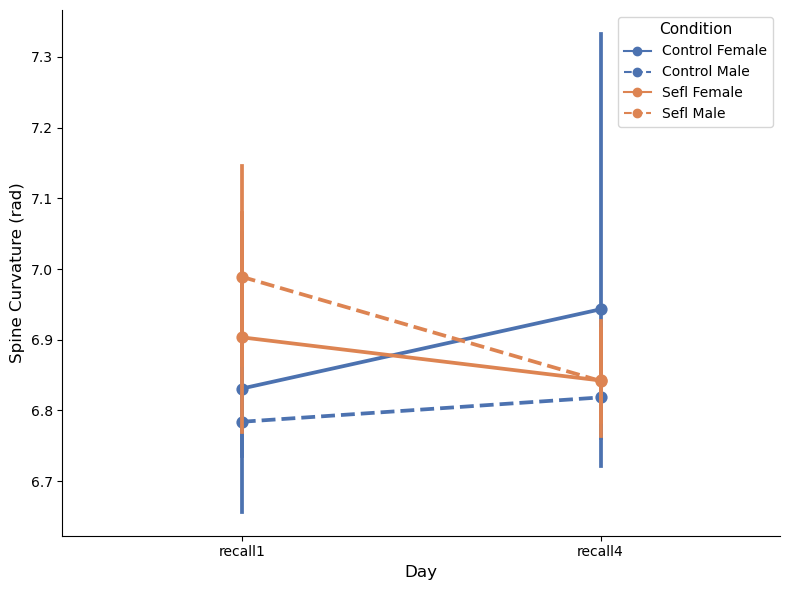

In [11]:
dlc.plot_kinematics_pointplot(curv_summary, ['condition', 'sex'], y_col='spine_curvature')
plt.ylabel('Spine Curvature (rad)')

In [31]:
cu_male = curv_summary[curv_summary["sex"] == "male"]

tools_male = kinematicsAnalysis(cu_male)

result_male = tools_male.repeated_measures_anova(
    dv="spine_curvature",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Male-Only ANOVA Result:")
print(result_male["anova_result"])


Male-Only ANOVA Result:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.285610    1   44  0.285610  5.077853  0.029268  0.103465   
1          day  0.133627    1   44  0.133627  1.950322  0.169558  0.042444   
2  Interaction  0.181175    1   44  0.181175  2.644301  0.111064  0.056691   

   eps  
0  NaN  
1  1.0  
2  NaN  


In [32]:
cu_female = curv_summary[curv_summary["sex"] == "female"]

tools_female = kinematicsAnalysis(cu_female)

result_female = tools_female.repeated_measures_anova(
    dv="spine_curvature",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Female-Only ANOVA Result:")
print(result_female["anova_result"])


Female-Only ANOVA Result:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.020822    1   17  0.020822  0.230268  0.637441  0.013364   
1          day  0.020294    1   17  0.020294  0.317883  0.580245  0.018356   
2  Interaction  0.024135    1   17  0.024135  0.378051  0.546791  0.021754   

   eps  
0  NaN  
1  1.0  
2  NaN  


In [34]:
cu_recall1 = curv_summary[curv_summary["day"] == "recall1"]

# Fit the ANOVA model
model1 = ols("spine_curvature ~ C(condition) * C(sex)", data=cu_recall1).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Sex at Recall1:")
print(anova_table1)


cu_recall4 = curv_summary[curv_summary["day"] == "recall4"]

# Fit the ANOVA model
model2 = ols("spine_curvature ~ C(condition) * C(sex)", data=cu_recall4).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × Sex at Recall4:")
print(anova_table2)



Two-Way ANOVA for Condition × Sex at Recall1:
                       sum_sq    df         F    PR(>F)
C(condition)         0.428269   1.0  4.502694  0.037845
C(sex)               0.019706   1.0  0.207181  0.650576
C(condition):C(sex)  0.056518   1.0  0.594213  0.443722
Residual             5.897070  62.0       NaN       NaN
Two-Way ANOVA for Condition × Sex at Recall4:
                       sum_sq    df         F    PR(>F)
C(condition)         0.002370   1.0  0.048963  0.825618
C(sex)               0.029921   1.0  0.618062  0.434812
C(condition):C(sex)  0.048442   1.0  1.000642  0.321107
Residual             2.953065  61.0       NaN       NaN


Text(62.597222222222214, 0.5, 'Spine Curvature (rad)')

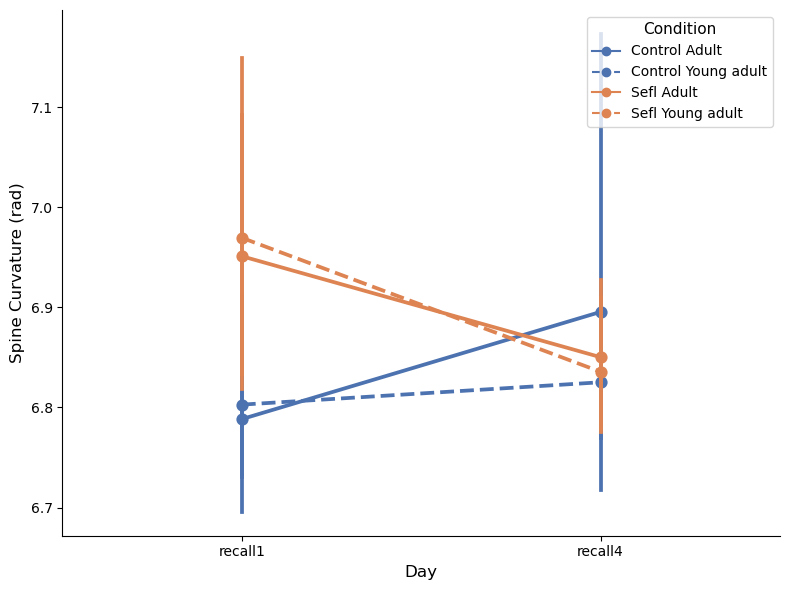

In [12]:
dlc.plot_kinematics_pointplot(curv_summary, ['condition', 'young'], y_col='spine_curvature')
plt.ylabel('Spine Curvature (rad)')

In [38]:
cu_ya = curv_summary[curv_summary["young"] == "Young Adult"]

tools_ya = kinematicsAnalysis(cu_ya)

result_ya = tools_ya.repeated_measures_anova(
    dv="spine_curvature",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Young Adult-Only ANOVA Result:")
print(result_ya["anova_result"])


Male-Only ANOVA Result:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.094216    1   36  0.094216  1.716285  0.198470  0.045505   
1          day  0.051803    1   36  0.051803  0.748549  0.392665  0.020369   
2  Interaction  0.068874    1   36  0.068874  0.995226  0.325127  0.026901   

   eps  
0  NaN  
1  1.0  
2  NaN  


In [40]:
cu_ad = curv_summary[curv_summary["young"] == "Adult"]

tools_ad = kinematicsAnalysis(cu_ad)

result_ad = tools_ad.repeated_measures_anova(
    dv="spine_curvature",
    within="day",
    between="condition",
    subject="cohort_id"
)

print("Adult-Only ANOVA Result:")
print(result_ad["anova_result"])


Adult-Only ANOVA Result:
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.043425    1   25  0.043425  0.494410  0.488464  0.019393   
1          day  0.007677    1   25  0.007677  0.112680  0.739914  0.004487   
2  Interaction  0.136154    1   25  0.136154  1.998338  0.169804  0.074017   

   eps  
0  NaN  
1  1.0  
2  NaN  


In [ ]:
cu_recall1 = curv_summary[curv_summary["day"] == "recall1"]

# Fit the ANOVA model
model1 = ols("spine_curvature ~ C(condition) * C(young)", data=cu_recall1).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × young at Recall1:")
print(anova_table1)


cu_recall4 = curv_summary[curv_summary["day"] == "recall4"]

# Fit the ANOVA model
model2 = ols("spine_curvature ~ C(condition) * C(young)", data=cu_recall4).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)

# Print the results
print("Two-Way ANOVA for Condition × young at Recall4:")
print(anova_table2)



Two-Way ANOVA for Condition × Sex at Recall1:
                       sum_sq    df         F    PR(>F)
C(condition)         0.428269   1.0  4.502694  0.037845
C(sex)               0.019706   1.0  0.207181  0.650576
C(condition):C(sex)  0.056518   1.0  0.594213  0.443722
Residual             5.897070  62.0       NaN       NaN
Two-Way ANOVA for Condition × Sex at Recall4:
                       sum_sq    df         F    PR(>F)
C(condition)         0.002370   1.0  0.048963  0.825618
C(sex)               0.029921   1.0  0.618062  0.434812
C(condition):C(sex)  0.048442   1.0  1.000642  0.321107
Residual             2.953065  61.0       NaN       NaN
